In [690]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
seaborn_custom_params = {'axes.spines.right': False, 'axes.spines.top': False}
sns.set_theme(context = 'notebook', style ='white', rc=seaborn_custom_params)
from itertools import product

from sklearn import set_config
set_config('diagram')
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Lasso,
    Ridge,
    ElasticNet
)

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

In [691]:
project_path = Path.cwd()
project_data_sources_path = project_path / 'data' / 'sources'
project_data_exports_path = project_path / 'data' / 'exports'

print(project_path)
print(project_data_sources_path)
print(project_data_exports_path)

/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/sources
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/exports


# User Defined Functions

## Data Imports

#### Summary DFs

In [692]:
summary_df = pd.read_csv(project_data_exports_path / 'summary_df.csv')
summary_2df = pd.read_csv(project_data_exports_path / 'summary_2df.csv')
summary_3df = pd.read_csv(project_data_exports_path / 'summary_3df.csv')

In [693]:
summary_df['window_type'] = 'expanding'
summary_2df['window_type'] = 'fixed_3'
summary_3df['window_type'] = 'fixed_5'

## Tiered DFs

In [694]:
tiered_results_df = pd.read_csv(project_data_exports_path / 'tiered_results_df.csv')
tiered_results_2df = pd.read_csv(project_data_exports_path / 'tiered_results_2df.csv')
tiered_results_3df = pd.read_csv(project_data_exports_path / 'tiered_results_3df.csv')

In [695]:
tiered_results_df['window_type'] = 'expanding'
tiered_results_2df['window_type'] = 'fixed_3'
tiered_results_3df['window_type'] = 'fixed_5'

### Outer Results

In [696]:
outer_results_df = pd.read_csv(project_data_exports_path / 'outer_results_df.csv')
outer_results_2df = pd.read_csv(project_data_exports_path / 'outer_results_2df.csv')
outer_results_3df = pd.read_csv(project_data_exports_path / 'outer_results_3df.csv')

In [697]:
outer_results_df['window_type'] = 'expanding'
outer_results_2df['window_type'] = 'fixed_3'
outer_results_3df['window_type'] = 'fixed_5'

### Leadership DF

In [698]:
leaderboard_df = pd.read_csv(project_data_exports_path / 'leaderboard_df.csv')
leaderboard_2df = pd.read_csv(project_data_exports_path / 'leaderboard_2df.csv')
leaderboard_3df = pd.read_csv(project_data_exports_path / 'leaderboard_3df.csv')

In [699]:
leaderboard_df['window_type'] = 'expanding'
leaderboard_2df['window_type'] = 'fixed_3'
leaderboard_3df['window_type'] = 'fixed_5'

### Pred DF

In [700]:
pred_df = pd.read_csv(project_data_exports_path / 'pred_df.csv')
pred_2df = pd.read_csv(project_data_exports_path / 'pred_2df.csv')
pred_3df = pd.read_csv(project_data_exports_path / 'pred_3df.csv')

In [701]:
pred_df['window_type'] = 'expanding'
pred_2df['window_type'] = 'fixed_3'
pred_3df['window_type'] = 'fixed_5'

### Perm All DF

In [702]:
perm_all_df = pd.read_csv(project_data_exports_path / 'perm_all_df.csv')
perm_all_2df = pd.read_csv(project_data_exports_path / 'perm_all_2df.csv')
perm_all_3df = pd.read_csv(project_data_exports_path / 'perm_all_3df.csv')

In [703]:
perm_all_df['window_type'] = 'expanding'
perm_all_2df['window_type'] = 'fixed_3'
perm_all_3df['window_type'] = 'fixed_5'

### Coef All DF

In [704]:
coef_all_df = pd.read_csv(project_data_exports_path / 'coef_all_df.csv')
coef_all_2df = pd.read_csv(project_data_exports_path / 'coef_all_2df.csv')
coef_all_3df = pd.read_csv(project_data_exports_path / 'coef_all_3df.csv')

In [705]:
coef_all_df['window_type'] = 'expanding'
coef_all_2df['window_type'] = 'fixed_3'
coef_all_3df['window_type'] = 'fixed_5'

### Tuning Expanded DF

In [706]:
tuning_expanded_df = pd.read_csv(project_data_exports_path / 'tuning_expanded_df.csv')
tuning_expanded_2df = pd.read_csv(project_data_exports_path / 'tuning_expanded_2df.csv')
tuning_expanded_3df = pd.read_csv(project_data_exports_path / 'tuning_expanded_3df.csv')

In [707]:
tuning_expanded_df['window_type'] = 'expanding'
tuning_expanded_2df['window_type'] = 'fixed_3'
tuning_expanded_3df['window_type'] = 'fixed_5'

## Concat Dataframes

In [708]:
tiered_all = pd.concat([tiered_results_df, tiered_results_2df, tiered_results_3df], ignore_index=True)
tiered_all.to_csv(project_data_exports_path / 'tiered_all.csv', index=False)
summary_all  = pd.concat([summary_df, summary_2df, summary_3df], ignore_index=True)
summary_all.to_csv(project_data_exports_path / 'summary_all.csv', index=False)
outer_all = pd.concat([outer_results_df, outer_results_2df, outer_results_3df], ignore_index=True)
pred_all = pd.concat([pred_df, pred_2df, pred_3df], ignore_index=True)
coef_all = pd.concat([coef_all_df, coef_all_2df, coef_all_3df], ignore_index=True)
perm_all = pd.concat([perm_all_df, perm_all_2df, perm_all_3df], ignore_index=True)

In [709]:
summary_all

,model_name,mean_train_auc,mean_test_auc,mean_auc_gap,mean_train_log_loss,mean_test_log_loss,mean_log_loss_gap,mean_test_brier,mean_test_accuracy,std_test_auc,n_splits,window_type
0,logit_l2,0.805318,0.787855,0.017463,0.535601,0.552059,0.016458,0.186260,0.714784,0.025028,9,expanding
1,logit_l1,0.805702,0.787768,0.017934,0.532680,0.549511,0.016831,0.185356,0.709152,0.025304,9,expanding
2,logit_elasticnet,0.805253,0.787619,0.017635,0.533732,0.549787,0.016055,0.185347,0.713810,0.024487,9,expanding
3,svc,0.809162,0.786148,0.023014,0.530052,0.551180,0.021128,0.186368,0.711641,0.024390,9,expanding
4,random_forest,0.882266,0.783242,0.099024,0.455704,0.553399,0.097695,0.187355,0.716454,0.026220,9,expanding
5,gradient_boosting,0.872526,0.775952,0.096574,0.478368,0.566705,0.088337,0.192297,0.707531,0.024033,9,expanding
6,logit_l2,0.800579,0.782112,0.018467,0.546149,0.562498,0.016349,0.190330,0.710898,0.026064,9,fixed_3
7,logit_elasticnet,0.796536,0.781547,0.014989,0.549427,0.562935,0.013508,0.190613,0.710530,0.028341,9,fixed_3
8,logit_l2,0.801698,0.782205,0.019492,0.538599,0.559894,0.021296,0.189069,0.715134,0.027111,7,fixed_5
9,logit_elasticnet,0.803455,0.782036,0.021419,0.532524,0.556326,0.023801,0.187724,0.715917,0.025883,7,fixed_5


In [710]:
summary_all_melt_df  = pd.melt(
    summary_all,
    id_vars=["model_name", "window_type"],
    value_vars=['mean_train_auc', 'mean_test_auc', 'mean_auc_gap', 'mean_train_log_loss', 'mean_test_log_loss', 'mean_log_loss_gap', 'mean_test_brier', 'mean_test_accuracy',],
    var_name='model_metric',
    value_name='value',
)
summary_all_melt_df

,model_name,window_type,model_metric,value
0,logit_l2,expanding,mean_train_auc,0.805318
1,logit_l1,expanding,mean_train_auc,0.805702
2,logit_elasticnet,expanding,mean_train_auc,0.805253
3,svc,expanding,mean_train_auc,0.809162
4,random_forest,expanding,mean_train_auc,0.882266
...,...,...,...,...
75,gradient_boosting,expanding,mean_test_accuracy,0.707531
76,logit_l2,fixed_3,mean_test_accuracy,0.710898
77,logit_elasticnet,fixed_3,mean_test_accuracy,0.710530
78,logit_l2,fixed_5,mean_test_accuracy,0.715134


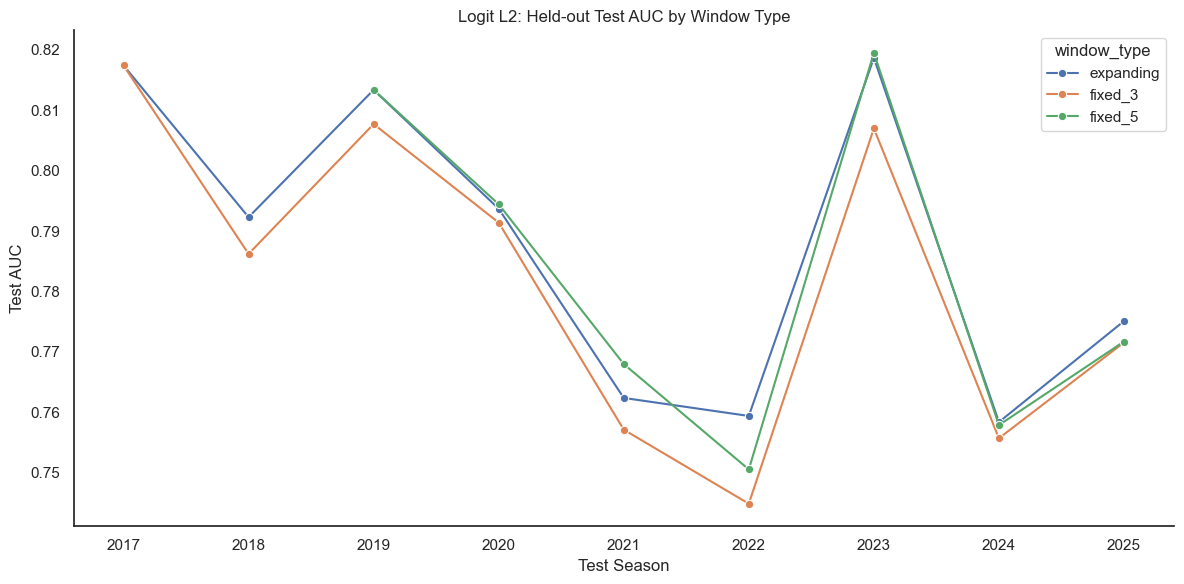

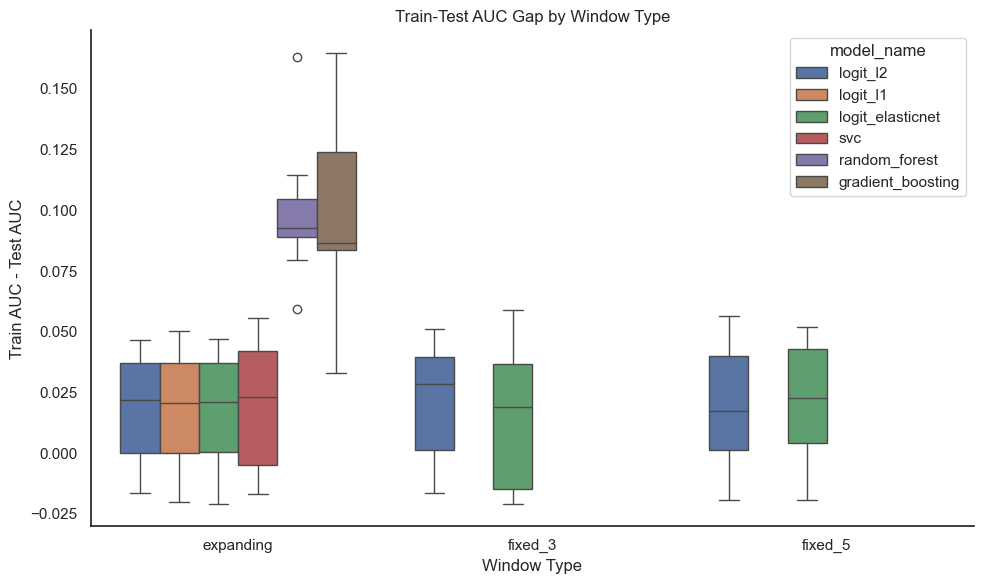

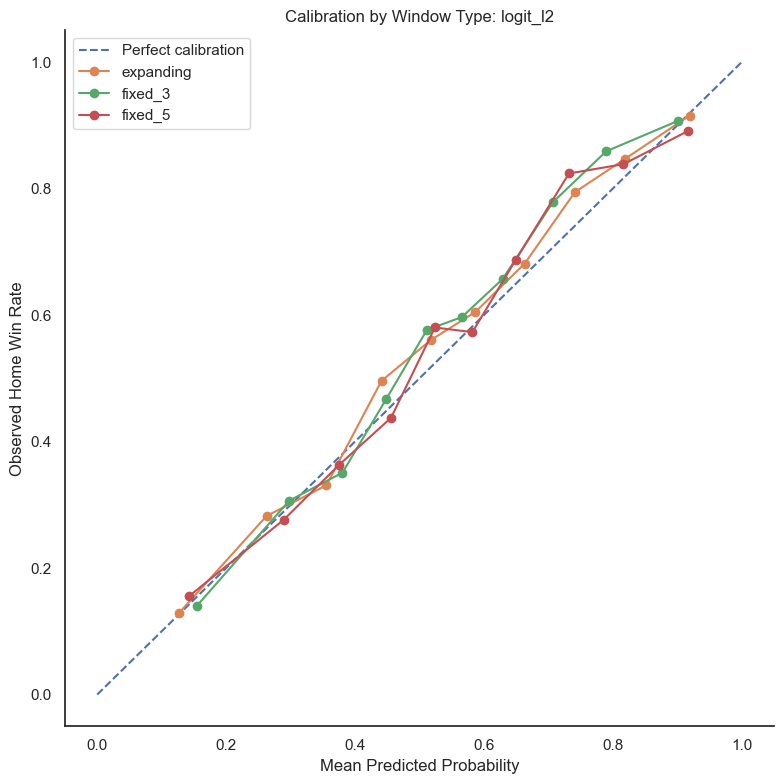

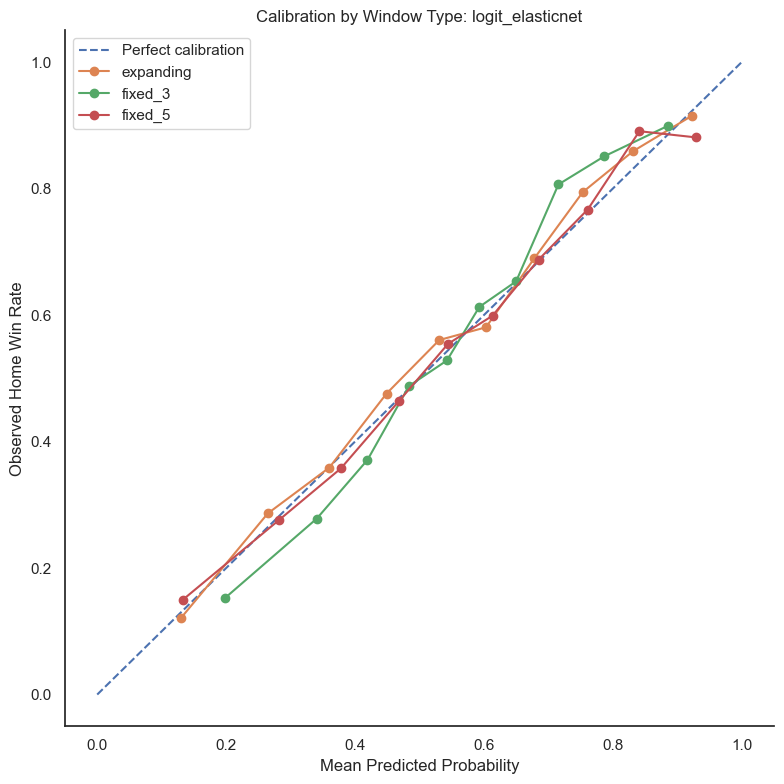

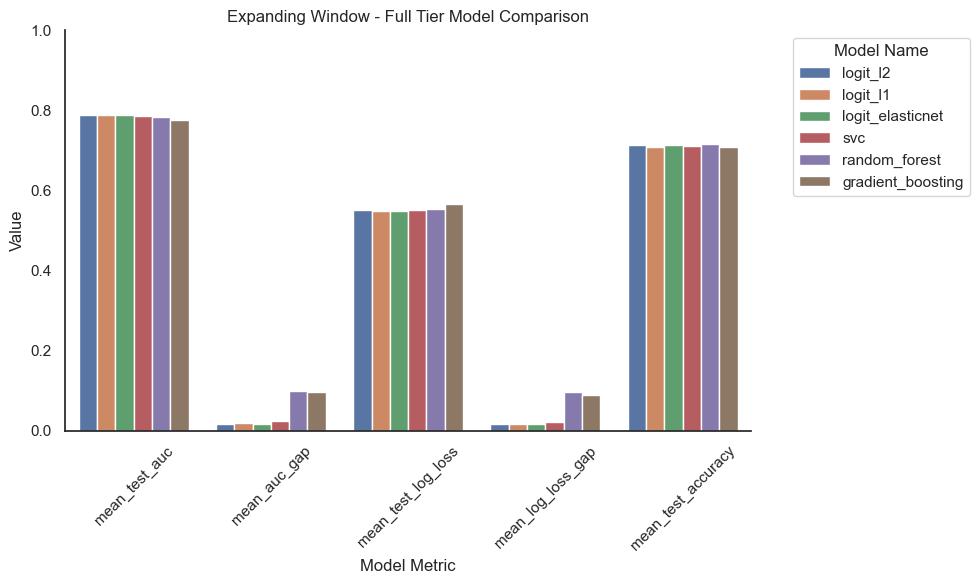

In [711]:
expanding_full_tier_comparison_bar_plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='w')
sns.barplot(
    data=summary_all_melt_df.loc[
        (summary_all_melt_df['model_metric'].isin(['mean_test_auc', 'mean_auc_gap', 'mean_test_log_loss', 'mean_log_loss_gap', 'mean_test_accuracy'])) & (summary_all_melt_df['window_type'].isin(['expanding']))
        ,:],
    x='model_metric',
    y='value',
    hue='model_name',
    errorbar=None,
    ax=ax,
)

ax.set_ylim(0,1)
ax.set_title('Expanding Window - Full Tier Model Comparison')
ax.set_xlabel('Model Metric')
ax.set_ylabel('Value')

ax.tick_params(axis='x', rotation=45)
ax.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()
expanding_full_tier_comparison_bar_plot.savefig(project_data_exports_path / 'expanding_full_tier_comparison_bar_plot.png', dpi=300, bbox_inches='tight');

In [712]:
# logit_l2_enet_plot_df = summary_all[
#     (summary_all['feature_set_name'] == 'full') &
#     (summary_all['model_name'].isin(['logit_l2', 'logit_elasticnet']))
# ].copy()

window_labels = {
    'expanding': 'Expanding',
    'fixed_3': 'Fixed 3',
    'fixed_5': 'Fixed 5',
    'fixed3': 'Fixed 3',
    'fixed5': 'Fixed 5',
}
model_labels = {
    'logit_l2': 'Logistic L2',
    'logit_elasticnet': 'Elastic Net'
}

logit_l2_enet_plot_df = summary_all.copy()

logit_l2_enet_plot_df['window_label'] = logit_l2_enet_plot_df['window_type'].map(window_labels)
logit_l2_enet_plot_df['model_label'] = logit_l2_enet_plot_df['model_name'].map(model_labels)

# order categories
logit_l2_enet_plot_df['window_label'] = pd.Categorical(
    logit_l2_enet_plot_df['window_label'],
    categories=['Expanding', 'Fixed 3', 'Fixed 5'],
    ordered=True
)

logit_l2_enet_plot_df['model_label'] = pd.Categorical(
    logit_l2_enet_plot_df['model_label'],
    categories=['Logistic L2', 'Elastic Net'],
    ordered=True
)


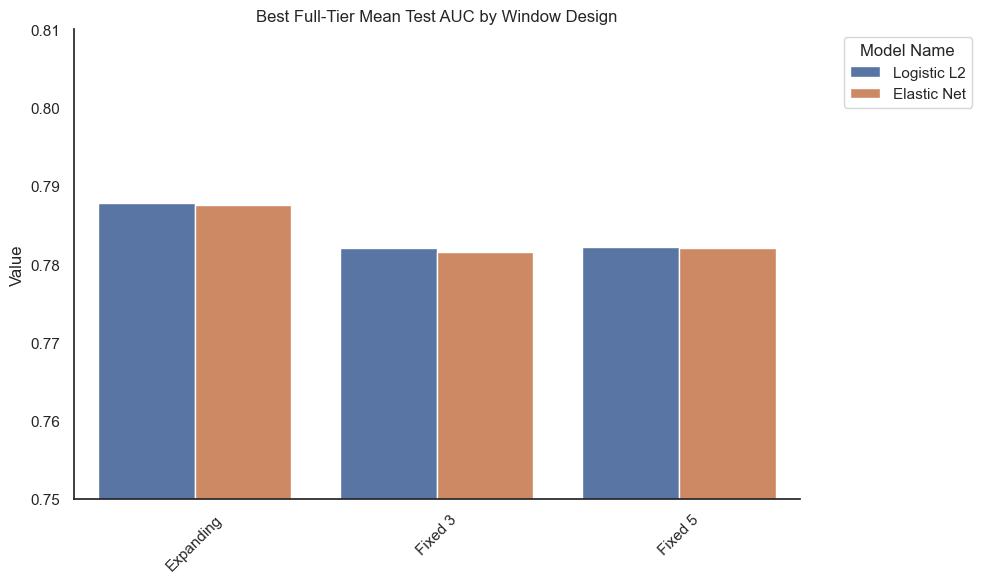

In [713]:
expanding_full_tier_comparison_preferred_bar_plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='w')
sns.barplot(
    data=logit_l2_enet_plot_df,
    x='window_label',
    y='mean_test_auc',
    hue='model_label',
    errorbar=None,
    ax=ax
)

ax.set_ylim(0.75, .81)
ax.set_title('Best Full-Tier Mean Test AUC by Window Design')
ax.set_xlabel('')
ax.set_ylabel('Value')

ax.tick_params(axis='x', rotation=45)
ax.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()
expanding_full_tier_comparison_preferred_bar_plot.savefig(project_data_exports_path / 'expanding_full_tier_comparison_preferred_bar_plot.png', dpi=300, bbox_inches='tight');

In [714]:
tiered_all

,model_name,best_params,train_start,train_end,test_season,n_train,n_test,train_auc,train_log_loss,train_brier,...,test_tn,test_fp,test_fn,test_tp,test_lr_pos,test_lr_neg,auc_gap,log_loss_gap,feature_set_name,window_type
0,logit_l2,{'C': 100},2014,2016,2017,823,278,0.728688,0.601548,0.207422,...,65,56,22,135,1.857939,0.260853,-0.049040,-0.030136,baseline,expanding
1,logit_l2,{'C': 100},2014,2017,2018,1101,278,0.743750,0.591794,0.202953,...,47,72,26,133,1.382512,0.414024,0.043417,0.024337,baseline,expanding
2,logit_l2,{'C': 100},2014,2018,2019,1379,276,0.736307,0.594327,0.204446,...,56,64,27,129,1.550481,0.370879,-0.016310,-0.021283,baseline,expanding
3,logit_l2,{'C': 100},2014,2019,2020,1655,222,0.740016,0.589158,0.202559,...,37,63,13,109,1.418163,0.287993,0.009319,0.006700,baseline,expanding
4,logit_l2,{'C': 100},2014,2020,2021,1877,282,0.738616,0.588904,0.202513,...,46,74,32,130,1.301301,0.515298,0.053070,0.031317,baseline,expanding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,logit_elasticnet,"{'C': 0.01, 'l1_ratio': 0.1}",2016,2020,2021,1336,282,0.800373,0.539249,0.181237,...,67,53,40,122,1.705101,0.442233,0.042143,0.031368,full,fixed_5
512,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2017,2021,2022,1336,279,0.813978,0.519884,0.173848,...,73,51,26,129,2.023529,0.284932,0.051907,0.057198,full,fixed_5
513,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2018,2022,2023,1337,291,0.800142,0.534535,0.179668,...,82,47,31,131,2.219464,0.301039,-0.019458,-0.020202,full,fixed_5
514,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2019,2023,2024,1350,288,0.802074,0.532330,0.178849,...,74,47,39,128,1.973245,0.381858,0.044020,0.047672,full,fixed_5


In [715]:
tiered_model_means = (
    tiered_all.groupby(['window_type', 'feature_set_name', 'model_name'], observed=True, as_index=False).agg(mean_test_auc=('test_auc', 'mean'))
)
tiered_model_means

,window_type,feature_set_name,model_name,mean_test_auc
0,expanding,baseline,gradient_boosting,0.724662
1,expanding,baseline,logit_elasticnet,0.721077
2,expanding,baseline,logit_l1,0.723196
3,expanding,baseline,logit_l2,0.721581
4,expanding,baseline,random_forest,0.727481
5,expanding,baseline,svc,0.710881
6,expanding,baseline_matchup,gradient_boosting,0.724713
7,expanding,baseline_matchup,logit_elasticnet,0.728653
8,expanding,baseline_matchup,logit_l1,0.727315
9,expanding,baseline_matchup,logit_l2,0.730989


In [716]:
best_by_tier = (
    tiered_model_means.sort_values(['window_type', 'feature_set_name', 'mean_test_auc'], ascending=[True, True, False]).reset_index(drop=True)
    .drop_duplicates(subset=['window_type', 'feature_set_name']).copy()
)
best_by_tier

,window_type,feature_set_name,model_name,mean_test_auc
0,expanding,baseline,random_forest,0.727481
6,expanding,baseline_matchup,random_forest,0.733009
12,expanding,baseline_performance,logit_l1,0.773069
18,expanding,baseline_talent,logit_l2,0.753901
24,expanding,baseline_talent_performance,logit_elasticnet,0.784831
30,expanding,full,logit_l2,0.787855
36,fixed_3,baseline,logit_elasticnet,0.723103
38,fixed_3,baseline_matchup,logit_l2,0.732286
40,fixed_3,baseline_performance,logit_l2,0.764178
42,fixed_3,baseline_talent,logit_l2,0.751449


In [717]:
feature_order = [
    'baseline',
    'baseline_matchup',
    'baseline_talent',
    'baseline_performance',
    'baseline_talent_performance',
    'full',
]

feature_labels = {
    'baseline': 'Baseline',
    'baseline_matchup': '+ Matchup',
    'baseline_talent': '+ Talent',
    'baseline_performance': '+ Performance',
    'baseline_talent_performance': '+ Talent +\nPerformance',
    'full': 'Full',
}

window_order = ['expanding', 'fixed_3', 'fixed_5']
window_labels = {
    'expanding': 'Expanding',
    'fixed_3': 'Fixed 3',
    'fixed_5': 'Fixed 5',
}

best_by_tier['feature_set_name'] = pd.Categorical(
    best_by_tier['feature_set_name'],
    categories=feature_order,
    ordered=True
)

best_by_tier['feature_label'] = best_by_tier['feature_set_name'].map(feature_labels)
best_by_tier['window_label'] = best_by_tier['window_type'].map(window_labels)


In [718]:
tiered_all_melted_df = pd.melt(
    tiered_all,
    id_vars=["model_name", "window_type", 'feature_set_name'],
    value_vars = ['test_auc', 'auc_gap', 'test_accuracy'],
    var_name='model_metric',
    value_name='value',
)
tiered_all_melted_df

,model_name,window_type,feature_set_name,model_metric,value
0,logit_l2,expanding,baseline,test_auc,0.777728
1,logit_l2,expanding,baseline,test_auc,0.700333
2,logit_l2,expanding,baseline,test_auc,0.752618
3,logit_l2,expanding,baseline,test_auc,0.730697
4,logit_l2,expanding,baseline,test_auc,0.685545
...,...,...,...,...,...
1543,logit_elasticnet,fixed_5,full,test_accuracy,0.670213
1544,logit_elasticnet,fixed_5,full,test_accuracy,0.724014
1545,logit_elasticnet,fixed_5,full,test_accuracy,0.731959
1546,logit_elasticnet,fixed_5,full,test_accuracy,0.701389


In [719]:
(
    tiered_all_melted_df.groupby(['model_name', 'window_type', 'feature_set_name', 'model_metric'], observed=True).agg({'value': 'first'}).
    reset_index()
)

,model_name,window_type,feature_set_name,model_metric,value
0,gradient_boosting,expanding,baseline,auc_gap,-0.025079
1,gradient_boosting,expanding,baseline,test_accuracy,0.705036
2,gradient_boosting,expanding,baseline,test_auc,0.754040
3,gradient_boosting,expanding,baseline_matchup,auc_gap,-0.025896
4,gradient_boosting,expanding,baseline_matchup,test_accuracy,0.705036
...,...,...,...,...,...
175,svc,expanding,baseline_talent_performance,test_accuracy,0.737410
176,svc,expanding,baseline_talent_performance,test_auc,0.817787
177,svc,expanding,full,auc_gap,-0.016775
178,svc,expanding,full,test_accuracy,0.730216


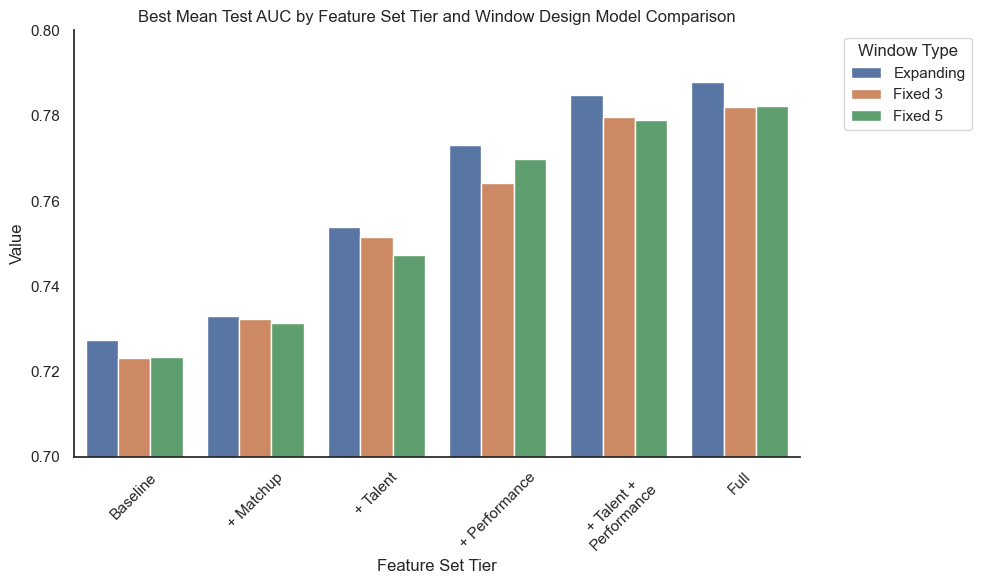

In [720]:
expanding_tiered_comparison_bar_plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='w')
sns.barplot(
    data=best_by_tier,
    x='feature_label',
    y='mean_test_auc',
    hue='window_label',
    errorbar=None,
    ax=ax,
)
ax.set_ylim(.7, .8)
ax.set_title('Best Mean Test AUC by Feature Set Tier and Window Design Model Comparison')
ax.set_xlabel('Feature Set Tier')
ax.set_ylabel('Value')

ax.tick_params(axis='x', rotation=45)
ax.legend(title='Window Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show();
expanding_tiered_comparison_bar_plot.savefig(project_data_exports_path / 'expanding_tiered_comparison_bar_plot.png', dpi=300, bbox_inches='tight');

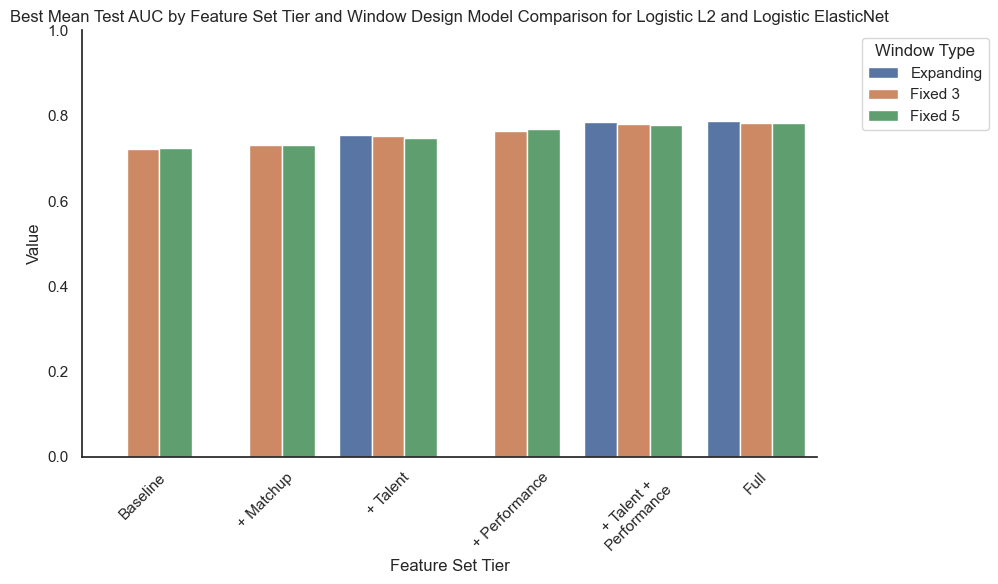

In [721]:
expanding_tiered_comparison_preferred_bar_plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='w')
sns.barplot(
    data=best_by_tier.loc[best_by_tier['model_name'].isin(['logit_l2', 'logit_elasticnet'])],
    x='feature_label',
    y='mean_test_auc',
    hue='window_label',
    errorbar=None,
    ax=ax,
)
# ax.set_ylim(.7, .8)
ax.set_ylim(0, 1)
ax.set_title('Best Mean Test AUC by Feature Set Tier and Window Design Model Comparison for Logistic L2 and Logistic ElasticNet')
ax.set_xlabel('Feature Set Tier')
ax.set_ylabel('Value')

ax.tick_params(axis='x', rotation=45)
ax.legend(title='Window Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show();
expanding_tiered_comparison_preferred_bar_plot.savefig(project_data_exports_path / 'expanding_tiered_comparison_preferred_bar_plot.png', dpi=300, bbox_inches='tight');

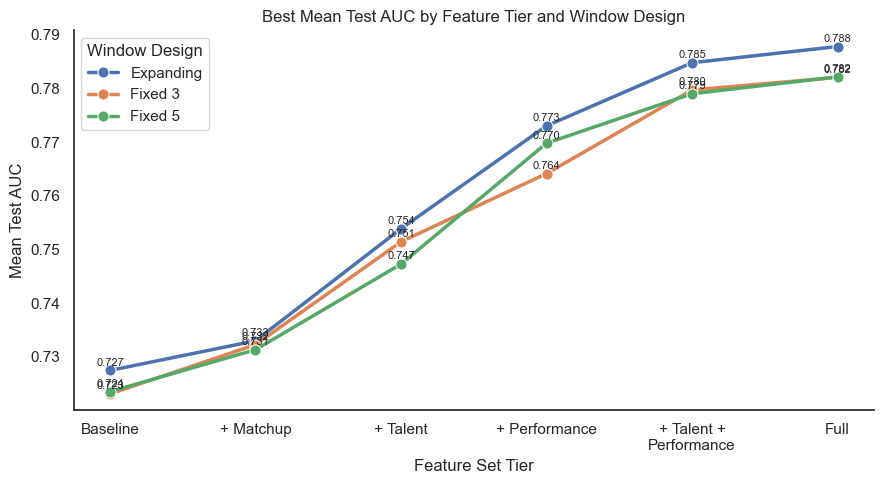

In [723]:
fixed_tiered_comparison_preferred_lineplot, ax = plt.subplots(figsize=(9, 5), facecolor='w')

sns.lineplot(
    data=best_by_tier,
    x='feature_label',
    y='mean_test_auc',
    hue='window_label',
    hue_order=['Expanding', 'Fixed 3', 'Fixed 5'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=ax
)

ax.set_title('Best Mean Test AUC by Feature Tier and Window Design')
ax.set_xlabel('Feature Set Tier')
ax.set_ylabel('Mean Test AUC')
ax.set_ylim(
    best_by_tier['mean_test_auc'].min() - 0.003,
    best_by_tier['mean_test_auc'].max() + 0.003
)

for _, row in best_by_tier.iterrows():
    ax.text(
        row['feature_label'],
        row['mean_test_auc'] + 0.0005,
        f"{row['mean_test_auc']:.3f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

ax.legend(title='Window Design', loc='upper left')
plt.tight_layout()
plt.show();
fixed_tiered_comparison_preferred_lineplot.savefig(project_data_exports_path / 'fixed_tiered_comparison_preferred_lineplot.png', dpi=300, bbox_inches='tight');

In [ ]:
summary_compare_df = (
    outer_all
    .groupby(["window_type", "model_name"], as_index=False)
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_test_auc=("test_auc", "mean"),
        mean_auc_gap=("auc_gap", "mean"),
        mean_train_log_loss=("train_log_loss", "mean"),
        mean_test_log_loss=("test_log_loss", "mean"),
        mean_test_brier=("test_brier", "mean"),
        mean_test_accuracy=("test_accuracy", "mean"),
        mean_test_precision=("test_precision", "mean"),
        mean_test_recall=("test_recall", "mean"),
        mean_test_f1=("test_f1", "mean"),
        std_test_auc=("test_auc", "std"),
        n_splits=("test_season", "count"),
    )
    .sort_values(["model_name", "mean_test_auc"], ascending=[True, False])
)

summary_compare_df.to_csv(project_data_exports_path / 'summary_compare_df.csv')
summary_compare_df

In [ ]:
plot_df = outer_all[outer_all["model_name"] == "logit_l2"].copy()

logit_l2_heldout_test_auc_by_window_plot, ax = plt.subplots(1, 1, figsize=(12, 6), facecolor="white")
sns.lineplot(
    data=plot_df,
    x="test_season",
    y="test_auc",
    hue="window_type",
    marker="o",
    ax=ax
)
ax.set_title("Logit L2: Held-out Test AUC by Window Type")
ax.set_xlabel("Test Season")
ax.set_ylabel("Test AUC")
logit_l2_heldout_test_auc_by_window_plot.tight_layout();
logit_l2_heldout_test_auc_by_window_plot.savefig(project_data_exports_path / 'logit_l2_heldout_test_auc_by_window_plot.png', dpi=300, bbox_inches="tight")

In [ ]:
train_test_auc_gap_by_window_type_plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor="white")
sns.boxplot(
    data=outer_all,
    x="window_type",
    y="auc_gap",
    hue="model_name",
    ax=ax
)
ax.set_title("Train-Test AUC Gap by Window Type")
ax.set_xlabel("Window Type")
ax.set_ylabel("Train AUC - Test AUC")
train_test_auc_gap_by_window_type_plot.tight_layout();
train_test_auc_gap_by_window_type_plot.savefig(project_data_exports_path / 'train_test_auc_gap_by_window_type_plot.png', dpi=300, bbox_inches="tight")

In [ ]:
def plot_calibration_by_window(pred_all, model_name, n_bins=10):
    temp = pred_all[pred_all["model_name"] == model_name].copy()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    for window_type in ["expanding", "fixed_3", "fixed_5"]:
        sub = temp[temp["window_type"] == window_type]
        if sub.empty:
            continue

        frac_pos, mean_pred = calibration_curve(
            sub["y_true"],
            sub["pred_prob"],
            n_bins=n_bins,
            strategy="quantile"
        )
        ax.plot(mean_pred, frac_pos, marker="o", label=window_type)

    ax.set_title(f"Calibration by Window Type: {model_name}")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Home Win Rate")
    ax.legend()

    fig.tight_layout()
    # plt.show()
    return fig

In [ ]:
logit_l2_calibration_by_window_plot = plot_calibration_by_window(pred_all, model_name="logit_l2");
logit_l2_calibration_by_window_plot.savefig(project_data_exports_path / 'logit_l2_calibration_by_window_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
logit_elasticnet_calibration_by_window_plot = plot_calibration_by_window(pred_all, model_name="logit_elasticnet");
logit_elasticnet_calibration_by_window_plot.savefig(project_data_exports_path / 'logit_elasticnet_calibration_by_window_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
coef_summary_df = (
    coef_all
    .groupby(["window_type", "model_name", "feature"], as_index=False)
    .agg(
        mean_coef=("coefficient", "mean"),
        mean_abs_coef=("abs_coefficient", "mean")
    )
)

coef_summary_df.to_csv(project_data_exports_path / 'coef_summary_df.csv')
coef_summary_df

In [ ]:
perm_summary_df = (
    perm_all
    .groupby(["window_type", "model_name", "feature"], as_index=False)
    .agg(
        mean_importance=("importance_mean", "mean")
    )
)

perm_summary_df.to_csv(project_data_exports_path / 'perm_summary_df.csv')
perm_summary_df